In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
# build the dataset
block_size = 3
def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [6]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((block_size*n_embd, n_hidden), generator=g) * (5/3)/((block_size*n_embd)**0.5)
# b1 = torch.randn((n_hidden,), generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn((vocab_size,), generator=g) * 0.01

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden)) 
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, W2, b2, bngain, bnbias] # b1,
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

12097


In [7]:
# Same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X and Y

    # forward pass
    emb = C[Xb] # (32, 3, 10)
    embcat = emb.view(emb.shape[0], -1) # (32, 30)
    hpreact = embcat @ W1 # + b1 # (32, 200)
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias

    with torch.no_grad():
        bnmean_running = 0.99 * bnmean_running + 0.01 * bnmeani
        bnstd_running = 0.99 * bnstd_running + 0.01 * bnstdi

    h = torch.tanh(hpreact) # (32, 200)
    logits = h @ W2 + b2 # (32, vocab_size)
    loss = F.cross_entropy(logits, Yb)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 3.3233
  10000/ 200000: 2.0321
  20000/ 200000: 2.5677
  30000/ 200000: 2.0131
  40000/ 200000: 2.2446
  50000/ 200000: 1.8895
  60000/ 200000: 2.0786
  70000/ 200000: 2.3688
  80000/ 200000: 2.2917
  90000/ 200000: 2.0242
 100000/ 200000: 2.3678
 110000/ 200000: 2.3134
 120000/ 200000: 1.6414
 130000/ 200000: 1.9306
 140000/ 200000: 2.2232
 150000/ 200000: 2.0025
 160000/ 200000: 2.0989
 170000/ 200000: 2.4944
 180000/ 200000: 2.0206
 190000/ 200000: 2.1705


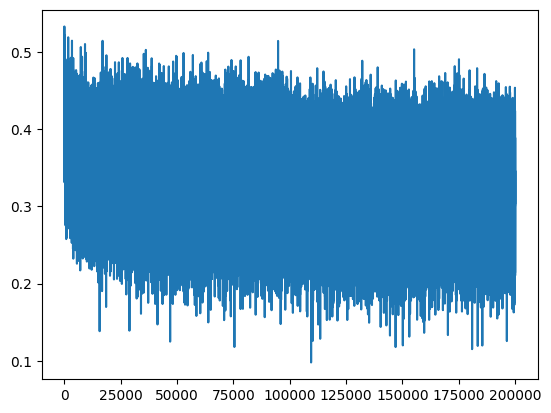

In [8]:
plt.plot(lossi);

In [9]:
# calibrate the batch norm at the end of training
with torch.no_grad():
    emb = C[Xtr] # (32, 3, 10)
    embcat = emb.view(emb.shape[0], -1) # (32, 30)
    hpreact = embcat @ W1 # + b1 # (32, 200)
    bnmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)

In [11]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x] # (32, 3, 10)
    embcat = emb.view(emb.shape[0], -1) # (32, 30)
    hpreact = embcat @ W1 # + b1 # (32, 200)
    hpreact = (hpreact - bnmean_running) / (bnstd_running) * bngain + bnbias
    h = torch.tanh(hpreact) # (32, 200)
    logits = h @ W2 + b2 # (32, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(f'{split}: {loss.item():.4f}')

split_loss('train')
split_loss('val')

train: 2.0674
val: 2.1061


In [12]:
# sample from the model
g = torch.Generator().manual_seed(2147483647)

for _ in range(20):

    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])] # (1, 3, 10)
        h = torch.tanh(emb.view(1, -1) @ W1) # (1, 200) + b1
        logits = h @ W2 + b2 # (1, vocab_size)
        probs = F.softmax(logits, dim=1) # (1, vocab_size)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        out.append(ix)
        context = context[1:] + [ix]
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))

tex.
briemtsurissaddry.
shrizishttlinellavk.
katdh.
samiyah.
jabshmilissmisrissandusslytsderkamrykshssdel.
tkhvirshifflspehrnikelvtrielswenslex.
sabibhgyns.
braysingldninatzithder.
dairithgbikshbudhb.
vard.
khyslqevghmarimiahhrishnn.
marisslmarivabel.
suyson.
gspten.
xierszadhviqkefflyziqtyn.
dmidsh.
saqsammigabriemiksissanfusaldylir.
farwealss.
selstellexsak.


In [45]:
# SUMMARY

class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / ((fan_in)**0.5)
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            return self.out + self.bias
        else:
            return self.out
        
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        if self.training:
            xmean = x.mean(0, keepdim=True)
            xvar = x.var(0, keepdim=True, unbiased=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]
    
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

n_embd = 10
n_hidden = 100
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
layers = [
    Linear(n_embd * block_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size), BatchNorm1d(vocab_size),
]

with torch.no_grad():
    # layers[-1].weight *= 0.1
    layers[-1].gamma *= 0.1
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= (5/3)

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

47551


In [46]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X and Y

    # forward pass
    emb = C[Xb] # (32, 3, 10)
    x = emb.view(emb.shape[0], -1) # (32, 30)
    for layer in layers:
        x = layer(x)
    logits = x
    loss = F.cross_entropy(logits, Yb)

    # backward pass
    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([(lr*p.grad.std() / p.data.std()).log10().item() for p in parameters])

    if i > 5000:
        break

      0/ 200000: 3.2870


Layer 2 output mean: -0.0020, std: 0.6286, saturated: 3.28%
Layer 5 output mean: -0.0043, std: 0.6516, saturated: 3.34%
Layer 8 output mean: -0.0046, std: 0.6514, saturated: 3.06%
Layer 11 output mean: 0.0011, std: 0.6524, saturated: 3.06%
Layer 14 output mean: -0.0081, std: 0.6559, saturated: 2.44%


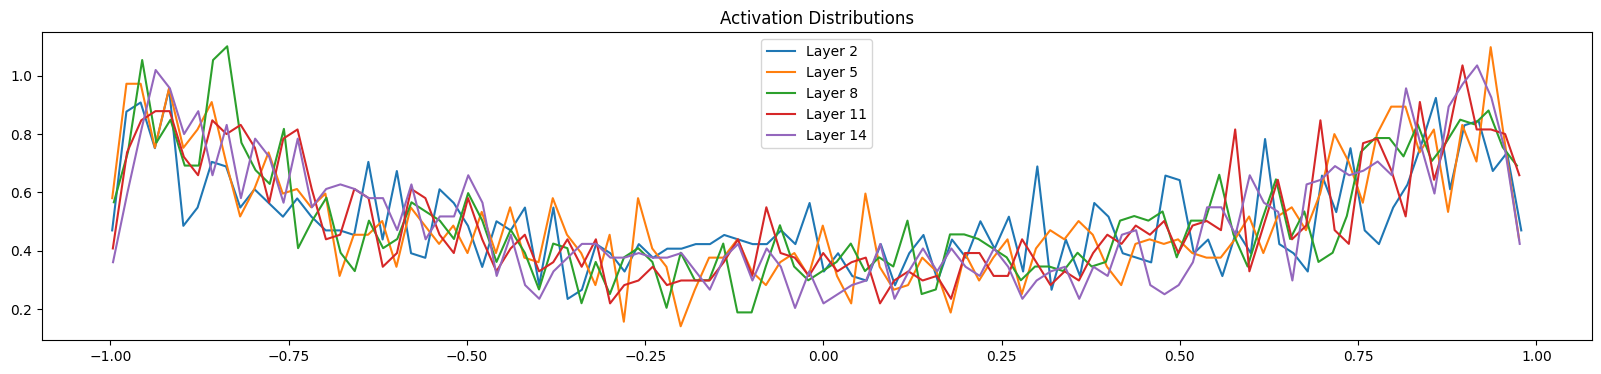

In [51]:
# visualize histograms
plt.figure(figsize=(20, 4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out
        print(f'Layer {i} output mean: {t.mean().item():.4f}, std: {t.std().item():.4f}, saturated: {((t.abs() > 0.97).float().mean().item() * 100):.2f}%')
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'Layer {i}')
plt.legend(legends)
plt.title('Activation Distributions');

Layer 2 output grad mean: 0.0000, std: 0.0041
Layer 5 output grad mean: 0.0000, std: 0.0038
Layer 8 output grad mean: -0.0000, std: 0.0036
Layer 11 output grad mean: -0.0000, std: 0.0032
Layer 14 output grad mean: -0.0000, std: 0.0031


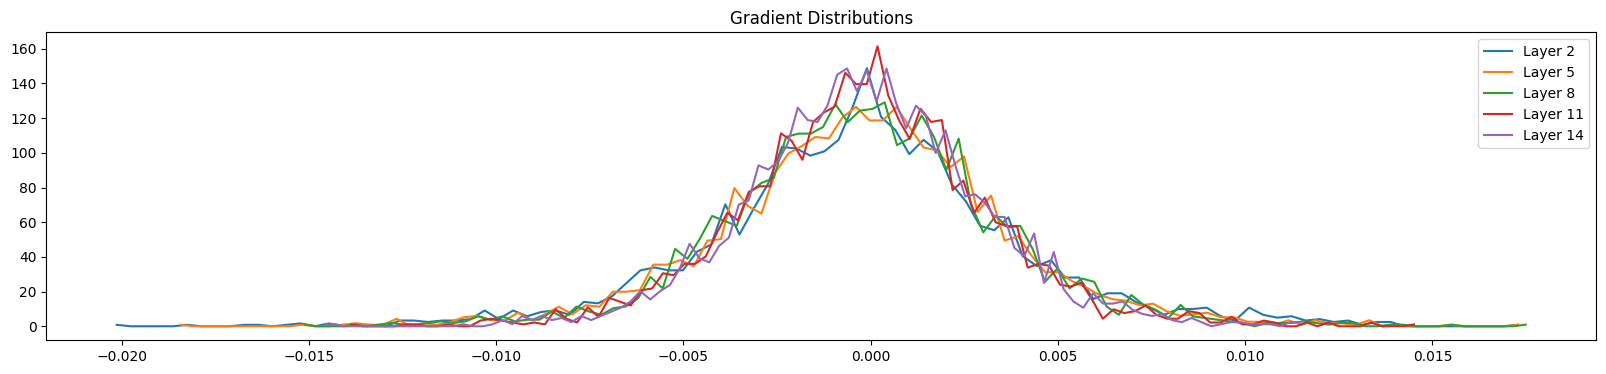

In [52]:
# visualize histograms
plt.figure(figsize=(20, 4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print(f'Layer {i} output grad mean: {t.mean().item():.4f}, std: {t.std().item():.4f}')
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'Layer {i}')
plt.legend(legends)
plt.title('Gradient Distributions');

weight 0 grad mean: -0.0000, std: 0.0122, grad:data ratio 0.0164
weight 1 grad mean: -0.0002, std: 0.0090, grad:data ratio 0.0309
weight 5 grad mean: 0.0000, std: 0.0073, grad:data ratio 0.0442
weight 9 grad mean: 0.0000, std: 0.0064, grad:data ratio 0.0387
weight 13 grad mean: 0.0000, std: 0.0060, grad:data ratio 0.0382
weight 17 grad mean: 0.0000, std: 0.0054, grad:data ratio 0.0330
weight 21 grad mean: -0.0003, std: 0.0102, grad:data ratio 0.0747


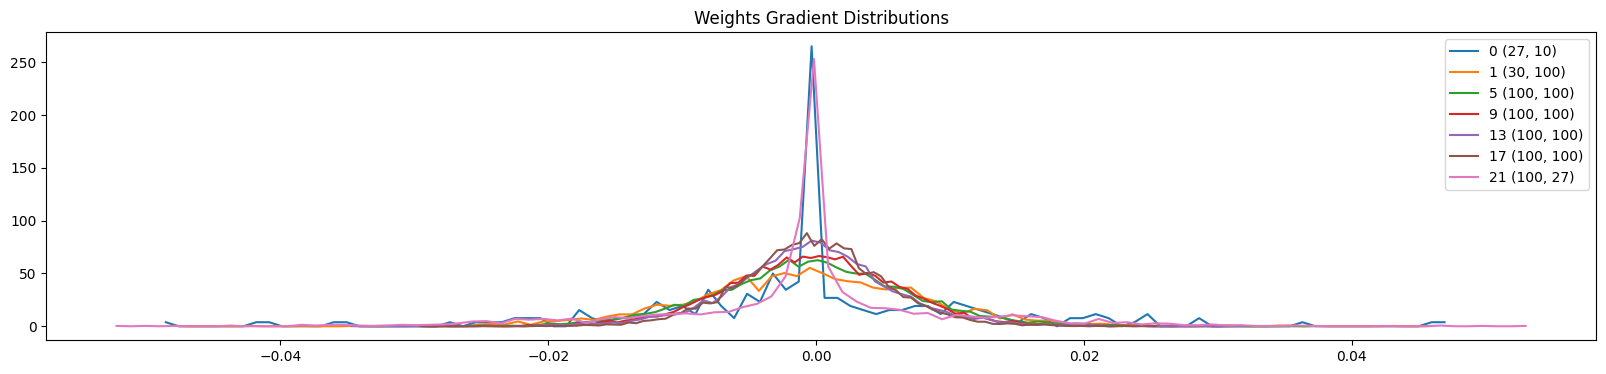

In [53]:
# visualize histograms
plt.figure(figsize=(20, 4))
legends = []
for i, p in enumerate(parameters):
    t = p.grad
    if p.ndim == 2:
        print(f"weight {i} grad mean: {t.mean().item():.4f}, std: {t.std().item():.4f}, grad:data ratio {(t.abs().std().item() / (p.abs().std().item())):.4f}")
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('Weights Gradient Distributions');

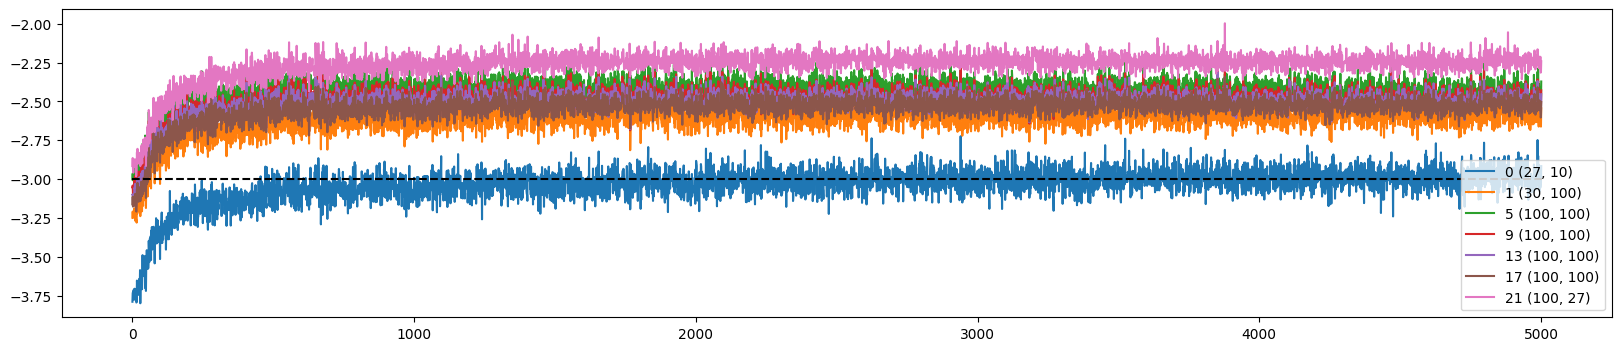

In [50]:
plt.figure(figsize=(20, 4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append(f'{i} {tuple(p.shape)}')
plt.plot([0, len(ud)], [-3, -3], 'k--')
plt.legend(legends);

In [28]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x] # (32, 3, 10)
    x = emb.view(emb.shape[0], -1) # (32, 30)
    for layer in layers:
        x = layer(x)
    logits = x
    loss = F.cross_entropy(logits, y)
    print(f'{split}: {loss.item():.4f}')

split_loss('train')
split_loss('val')

train: 1.9645
val: 2.0885


In [29]:
# sample from the model
g = torch.Generator().manual_seed(2147483647)

for _ in range(20):

    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])] # (1, 3, 10)
        x = emb.view(1, -1) # (1, 30)
        for layer in layers:
            x = layer(x)
        logits = x
        probs = F.softmax(logits, dim=1) # (1, vocab_size)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        out.append(ix)
        context = context[1:] + [ix]
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))

celia.
mouhamikima.
kayden.
maima.
taine.
kayla.
andr.
samiyah.
javari.
mari.
moriella.
kinzie.
darek.
emma.
sade.
eniavion.
ryonst.
hunte.
bron.
lucc.
